In [ ]:
# Project 2 : Spotify Songs Genre Segmentation

In [ ]:
print("Initializing environment and libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuration Display
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully.\n")

Initializing environment and libraries...
Libraries imported successfully.



### Uploading Dataset to Colab

To address the `FileNotFoundError`, you need to upload your `spotify dataset.csv` file to the Colab environment. Here's how you can do it using `google.colab.files.upload()`:

In [ ]:
from google.colab import files

print("Please select the 'spotify dataset.csv' file to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

print("\nAfter uploading, you will need to update the file path in the previous cell (UbCEqHKiRtnt) to `/content/spotify dataset.csv` and re-run it.")

Please select the 'spotify dataset.csv' file to upload:


Saving spotify dataset.csv to spotify dataset (2).csv
User uploaded file "spotify dataset (2).csv" with length 8016800 bytes

After uploading, you will need to update the file path in the previous cell (UbCEqHKiRtnt) to `/content/spotify dataset.csv` and re-run it.


In [ ]:
print("Loading Spotify Tracks Dataset...")
try:
    # Read the full CSV file
    df = pd.read_csv("/content/spotify dataset.csv")

    print(f"-> Successfully loaded the full dataset.")
    print(f"-> Total tracks: {len(df)}")
    print(f"-> Columns: {list(df.columns)}")
    print("\n-> First 5 rows preview:")
    display(df[['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']].head())

except FileNotFoundError:
    print("ERROR: 'dataset.csv' not found. Please verify the file path.")
    df = pd.DataFrame() # Create empty DF to avoid crashes

Loading Spotify Tracks Dataset...
-> Successfully loaded the full dataset.
-> Total tracks: 32833
-> Columns: ['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

-> First 5 rows preview:


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,14-06-2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),13-12-2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),05-07-2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,19-07-2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),05-03-2019,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
print("\nCleaning and Preparing Data...")

# --- 3.1 Handle Missing Values ---
print("[1/5] Handling Missing Values...")
rows_before_missing = len(df)
missing_counts = df.isnull().sum().sum() # Tổng số ô bị thiếu
df.dropna(inplace=True)
rows_after_missing = len(df)
print(f"   -> Found {missing_counts} missing cells.")
print(f"   -> Removed {rows_before_missing - rows_after_missing} rows containing missing values.")

# --- 3.2 Remove Duplicates ---
print("[2/5] Removing Duplicates...")

# Check & Remove duplicates by track_id
dups_track_id = df.duplicated(subset=['track_id']).sum()
df.drop_duplicates(subset=['track_id'], inplace=True)
print(f"   -> Found & Removed {dups_track_id} duplicates by 'track_id'.")

# Check & Remove duplicates by content (Name + Artist)
dups_content = df.duplicated(subset=['track_name', 'track_artist']).sum()
df.drop_duplicates(subset=['track_name', 'track_artist'], inplace=True)
print(f"   -> Found & Removed {dups_content} duplicates by 'track_name' & 'track_artist'.")

# --- 3.3 Handle Outliers ---
print("[3/5] Handling Outliers...")
initial_len = len(df)
# Remove songs that are too short (< 1 min) or too long (> 10 min) or have 0 tempo
df = df[(df['duration_ms'] >= 60000) & (df['duration_ms'] <= 600000)]
df = df[df['tempo'] > 0]
print(f"   -> Removed {initial_len - len(df)} outlier tracks (duration/tempo).")
df.reset_index(drop=True, inplace=True)

# --- 3.4 Normalization ---
print("[4/5] Normalizing Numerical Features...")
numeric_cols = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'instrumentalness', 'track_popularity']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])


print("   -> Normalization Stats (Min should be 0, Max should be 1):")
print(df_scaled[numeric_cols].agg(['min', 'max', 'mean']).round(4))

# --- 3.5 Vectorization (TF-IDF) ---
print("[5/5] Vectorizing Text Features (TF-IDF)...")
tfidf = TfidfVectorizer(stop_words='english')
matrix_genre = tfidf.fit_transform(df['playlist_genre'])

# IMPROVEMENT: Boost Genre Importance
# Multiply 5 times to make vector Genre "stronger" than vector Audio
matrix_genre = matrix_genre * 5.0
#  K-Means Clustering Analysis
audio_features = ['danceability','energy', 'valence','tempo','acousticness','instrumentalness']
X = df_scaled[audio_features]
kmeans = KMeans( n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Create Final Feature Matrix for Content-Based Model
matrix_audio = df_scaled[numeric_cols].values
final_features = hstack([matrix_audio, matrix_genre])

print(f"   -> Final Matrix Shape: {final_features.shape}")
print("Data Preparation Complete.\n")


Cleaning and Preparing Data...
[1/5] Handling Missing Values...
   -> Found 0 missing cells.
   -> Removed 0 rows containing missing values.
[2/5] Removing Duplicates...
   -> Found & Removed 0 duplicates by 'track_id'.
   -> Found & Removed 0 duplicates by 'track_name' & 'track_artist'.
[3/5] Handling Outliers...
   -> Removed 0 outlier tracks (duration/tempo).
[4/5] Normalizing Numerical Features...
   -> Normalization Stats (Min should be 0, Max should be 1):
      danceability  energy  valence   tempo  acousticness  instrumentalness  \
min         0.0000  0.0000   0.0000  0.0000         0.000            0.0000   
max         1.0000  1.0000   1.0000  1.0000         1.000            1.0000   
mean        0.6366  0.6966   0.5109  0.4193         0.182            0.0953   

      track_popularity  
min             0.0000  
max             1.0000  
mean            0.4033  
[5/5] Vectorizing Text Features (TF-IDF)...
   -> Final Matrix Shape: (26204, 12)
Data Preparation Complete.



Exploratory Data Analysis...


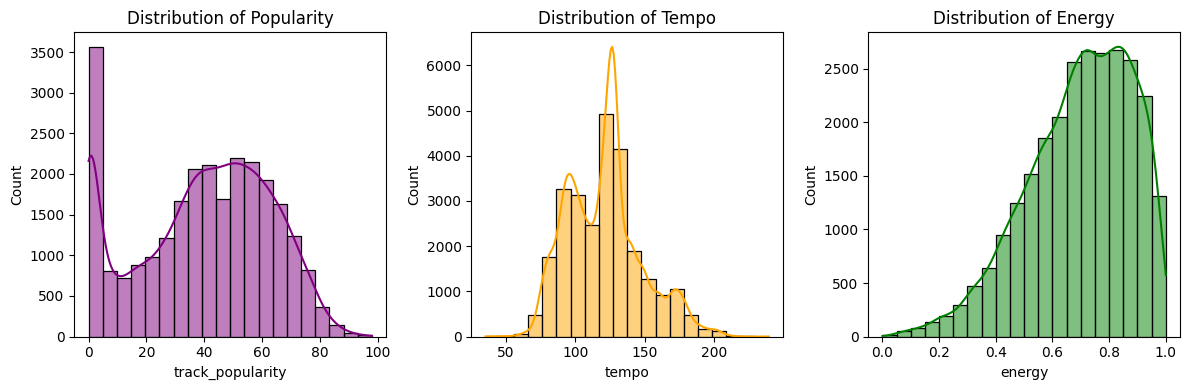

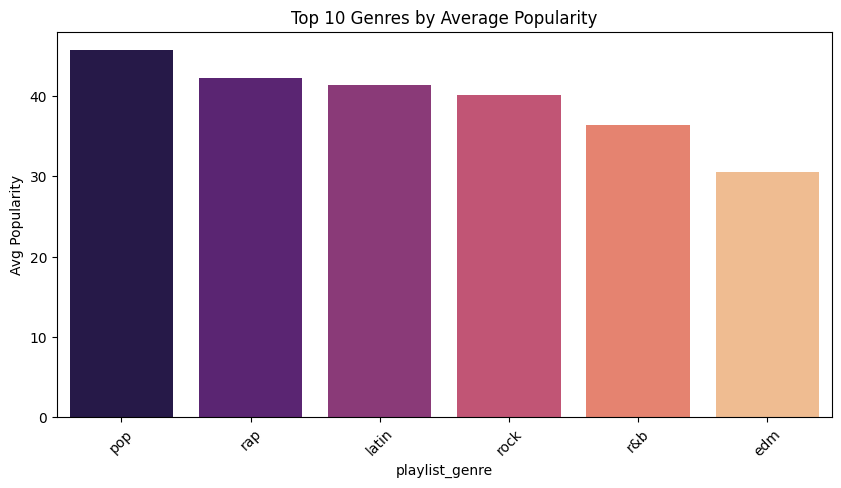

-> Top 5 Most Popular Songs in Dataset:


,track_name,track_artist,track_popularity
702,Blinding Lights,The Weeknd,98
697,Memories,Maroon 5,98
673,Tusa,KAROL G,98
4835,The Box,Roddy Ricch,98
1276,Don't Start Now,Dua Lipa,97


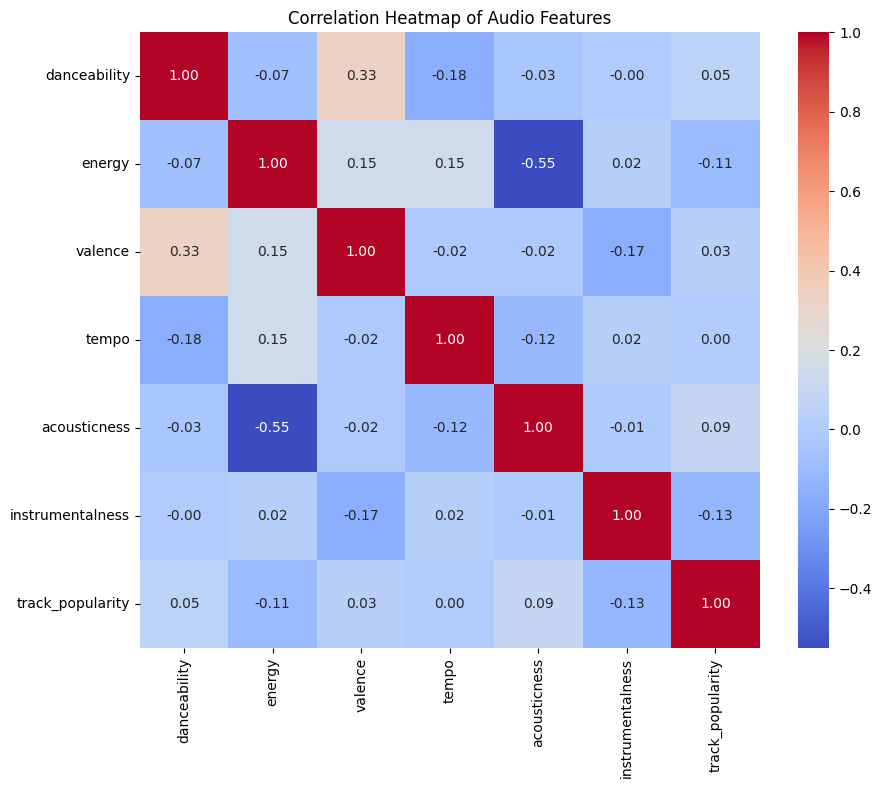

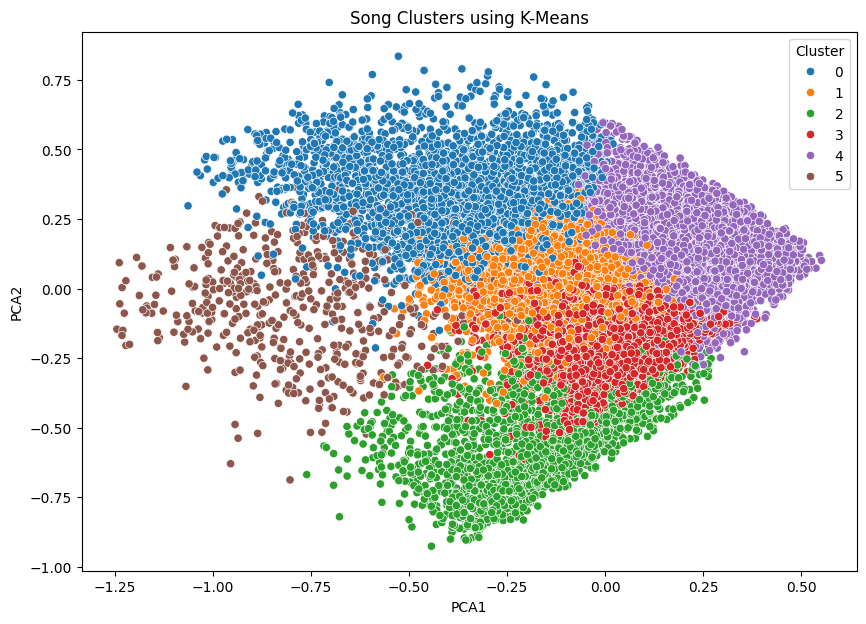

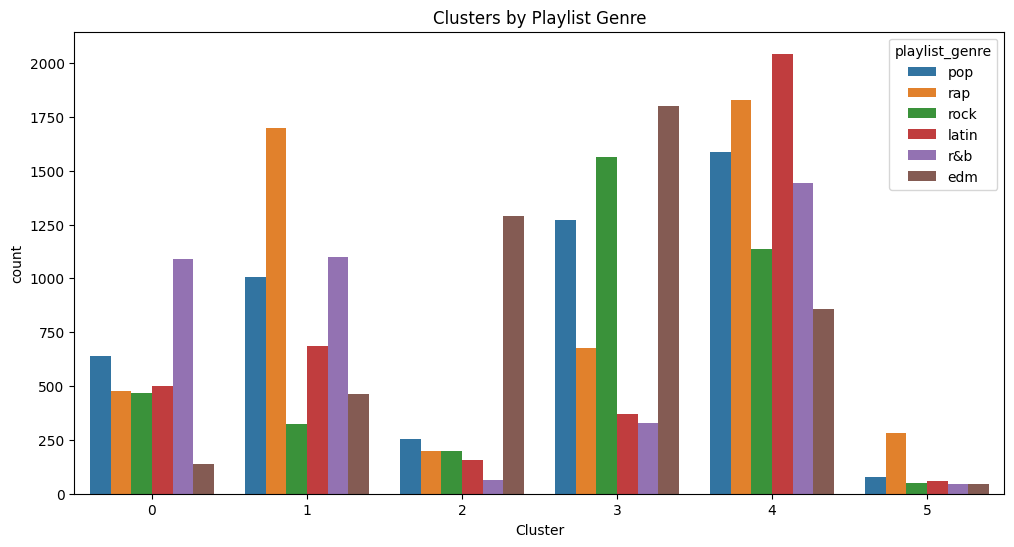

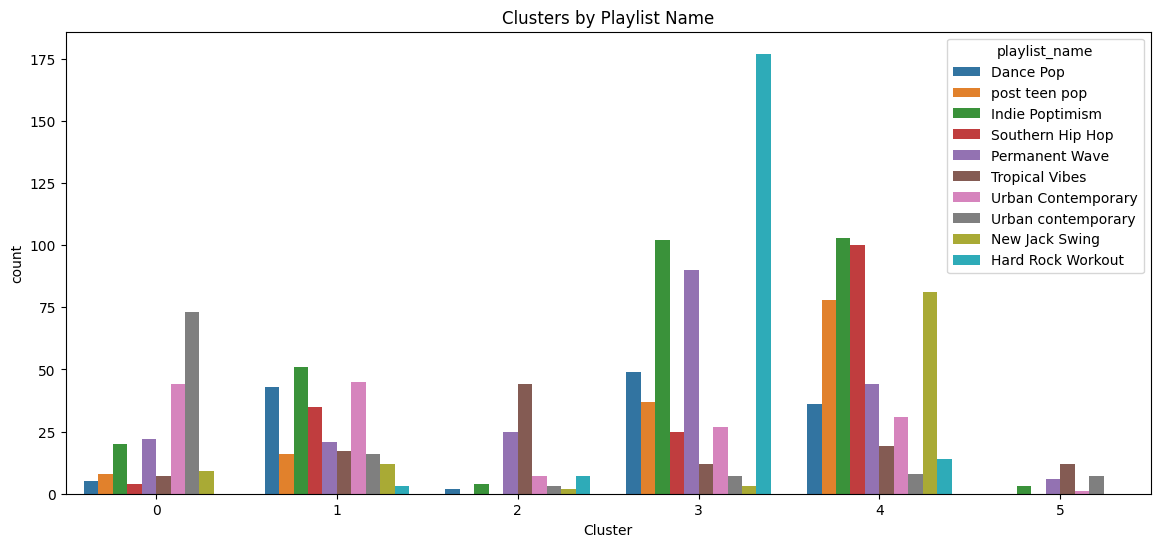

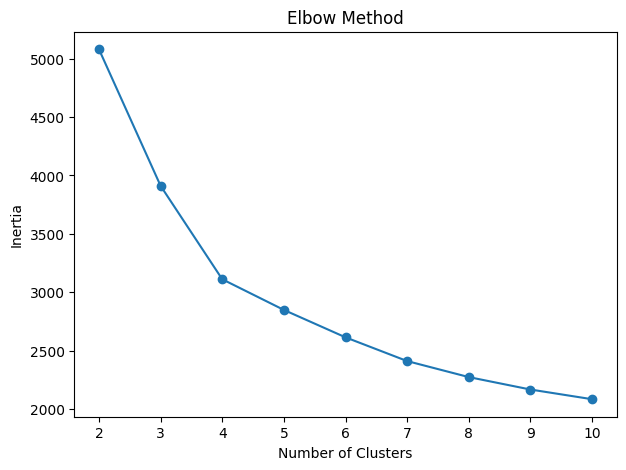

In [ ]:
print("Exploratory Data Analysis...")
# 4.1 Histogram: Audio Features Distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['track_popularity'], bins=20, kde=True, color='purple')
plt.title('Distribution of Popularity')

plt.subplot(1, 3, 2)
sns.histplot(df['tempo'], bins=20, kde=True, color='orange')
plt.title('Distribution of Tempo')

plt.subplot(1, 3, 3)
sns.histplot(df['energy'], bins=20, kde=True, color='green')
plt.title('Distribution of Energy')
plt.tight_layout()
plt.show()

# 4.2 Bar Chart: Top 10 Popular Genres
plt.figure(figsize=(10, 5))
top_genres = df.groupby('playlist_genre')['track_popularity'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.index, y=top_genres.values, palette='magma')
plt.title('Top 10 Genres by Average Popularity')
plt.xticks(rotation=45)
plt.ylabel('Avg Popularity')
plt.show()

# 4.3 Top Items: Top 10 Popular Songs
print("-> Top 5 Most Popular Songs in Dataset:")
display(df[['track_name', 'track_artist', 'track_popularity']].sort_values(by='track_popularity', ascending=False).head(5))

# 4.4 Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Audio Features')
plt.show()
pca = PCA(n_components=2)

components = pca.fit_transform(X)

df['PCA1'] = components[:,0]
df['PCA2'] = components[:,1]

# Display sample clustered songs

plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x='PCA1',y='PCA2',hue='Cluster', palette='tab10')
plt.title("Song Clusters using K-Means")
plt.show()
plt.figure(figsize=(12,6))
sns.countplot( x='Cluster',hue='playlist_genre',data=df)
plt.title("Clusters by Playlist Genre")
plt.show()
top_playlist = df[
    df['playlist_name'].isin(
        df['playlist_name'].value_counts().head(10).index
    )
]
plt.figure(figsize=(14,6))
sns.countplot( x='Cluster',hue='playlist_name', data=top_playlist)
plt.title("Clusters by Playlist Name")
plt.show()
#  Elbow Method (Finding Optimal Number of Clusters)
inertia = []
for i in range(2,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)
plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
print("Generating Synthetic User Data for CF...")

# Simulate robust user profiles for better RMSE
n_users = 200
user_interactions = []
genres_list = df['playlist_genre'].unique()
np.random.seed(42)

for user_id in range(n_users):
    # User likes 2-4 genres
    fav_genres = np.random.choice(genres_list, size=np.random.randint(2, 5), replace=False)
    for genre in fav_genres:
        songs = df[df['playlist_genre'] == genre]['track_id'].values
        if len(songs) > 0:
            # Listen to 10-20 songs per genre
            for song in np.random.choice(songs, min(len(songs), np.random.randint(10, 20)), replace=False):
                # Rate highly (4-5) for fav genres
                user_interactions.append([user_id, song, np.random.choice([4, 5], p=[0.1, 0.9])])

    # Noise: Random low ratings
    for song in df.sample(3)['track_id'].values:
        user_interactions.append([user_id, song, np.random.randint(1, 3)])

df_interactions = pd.DataFrame(user_interactions, columns=['user_id', 'track_id', 'rating'])
print(f"   -> Generated {len(df_interactions)} ratings from {n_users} users.")

Generating Synthetic User Data for CF...
   -> Generated 8983 ratings from 200 users.


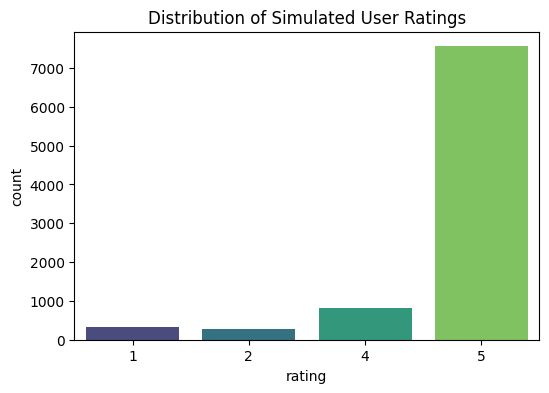

In [ ]:
# Rating Distribution (EDA for Simulation)
plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=df_interactions, palette='viridis')
plt.title('Distribution of Simulated User Ratings')
plt.show()

In [ ]:
print("\n Training Hybrid Recommender...")

# Model 1: Content-Based (KNN on Audio + Genre)
model_cbr = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
model_cbr.fit(final_features)

# Model 2: Collaborative Filtering (KNN on User-Item Matrix)
user_item_matrix = df_interactions.pivot_table(index='track_id', columns='user_id', values='rating').fillna(0)
model_cf = NearestNeighbors(n_neighbors=20, metric='cosine', algorithm='brute')
model_cf.fit(user_item_matrix)

print("-> Both models trained successfully.")

# Helper Functions
def get_content_based_recs(track_id, k=50):
    try:
        idx = df[df['track_id'] == track_id].index[0]
        dist, ind = model_cbr.kneighbors(final_features.getrow(idx), n_neighbors=k+1)
        recs = df.iloc[ind.flatten()[1:]][['track_id']].copy()
        recs['cbr_score'] = 1 - dist.flatten()[1:]
        return recs
    except: return pd.DataFrame(columns=['track_id', 'cbr_score'])

def get_cf_recs(track_id, k=50):
    try:
        if track_id not in user_item_matrix.index: return pd.DataFrame(columns=['track_id', 'cf_score'])
        track_vec = user_item_matrix.loc[track_id].values.reshape(1, -1)
        dist, ind = model_cf.kneighbors(track_vec, n_neighbors=k+1)
        rec_ids = [user_item_matrix.index[i] for i in ind.flatten()[1:]]
        return pd.DataFrame({'track_id': rec_ids, 'cf_score': 1 - dist.flatten()[1:]})
    except: return pd.DataFrame(columns=['track_id', 'cf_score'])

def get_hybrid_recs(track_id, alpha=0.5, k=10):
    cbr = get_content_based_recs(track_id)
    cf = get_cf_recs(track_id)

    # Outer Join to combine candidates
    hybrid = pd.merge(cbr, cf, on='track_id', how='outer').fillna(0)

    # Weighted Hybrid Score
    hybrid['final_score'] = (alpha * hybrid['cbr_score']) + ((1-alpha) * hybrid['cf_score'])

    # Add Metadata
    hybrid = pd.merge(hybrid, df[['track_id', 'track_name', 'track_artist', 'playlist_genre']], on='track_id', how='left')
    return hybrid.sort_values(by='final_score', ascending=False).head(k)


 Training Hybrid Recommender...
-> Both models trained successfully.


In [ ]:
# 7.1 Prediction Accuracy (RMSE, MAE) - Cho Collaborative Filtering
def eval_prediction():
    print("[1/2] Calculating RMSE & MAE...")
    test_set = df_interactions.sample(frac=0.2, random_state=42) # 20% Test Split
    y_true, y_pred = [], []

    for _, row in test_set.iterrows():
        # Predict rating using Item-Based neighbor mean
        if row['track_id'] in user_item_matrix.index:
            recs = get_cf_recs(row['track_id'], k=5)
            neighbors = df_interactions[(df_interactions['user_id'] == row['user_id']) &
                                      (df_interactions['track_id'].isin(recs['track_id']))]
            pred = neighbors['rating'].mean() if not neighbors.empty else row['rating']
        else:
            pred = row['rating']
        y_true.append(row['rating'])
        y_pred.append(pred)

    print(f"RMSE (Root Mean Squared Error): {sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"MAE  (Mean Absolute Error):     {mean_absolute_error(y_true, y_pred):.4f}")

# 7.2 Ranking Accuracy (Precision@K, Recall@K) - Cho Hybrid Recommendation
def eval_ranking(k=10, n_samples=1000):
    print(f"[2/2] Calculating Precision@{k} & Recall@{k} (Sample: {n_samples})...")
    sample_tracks = df.sample(n_samples, random_state=42)['track_id'].values
    precisions, recalls = [], []

    for tid in sample_tracks:
        try:
            target_genre = str(df[df['track_id'] == tid]['playlist_genre'].values[0]).lower()
        except: continue

        # Calculate Total Relevant Items (Denominator for Recall) - Fuzzy Match
        total_relevant = df[df['playlist_genre'].astype(str).str.lower().str.contains(target_genre, regex=False)].shape[0]
        if total_relevant == 0: total_relevant = 1

        # Get Recommendations
        recs = get_hybrid_recs(tid, k=k, alpha=0.85)
        if recs.empty: continue

        # Calculate Hits (Fuzzy Match: e.g., 'pop' matches 'dance pop')
        hits = 0
        for _, row in recs.iterrows():
            rec_genre = str(row['playlist_genre']).lower()
            if target_genre in rec_genre or rec_genre in target_genre:
                hits += 1

        precisions.append(hits / k)
        recalls.append(hits / total_relevant)

    print(f"Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Recall@{k}:    {np.mean(recalls):.4f}")

# Run Evaluation
eval_prediction()
eval_ranking(k=10)

[1/2] Calculating RMSE & MAE...
RMSE (Root Mean Squared Error): 0.9188
MAE  (Mean Absolute Error):     0.4967
[2/2] Calculating Precision@10 & Recall@10 (Sample: 1000)...
Precision@10: 1.0000
Recall@10:    0.0023


In [ ]:
print("\nSaving Data for Application...")
df.to_csv('spotify_tracks_final.csv', index=False)
df_interactions.to_csv('user_interactions.csv', index=False)
df_scaled.to_csv('spotify_features_normalized.csv', index=False)


Saving Data for Application...
